# Tarea 4: Modelos de Clasificación (MDS, Primavera 2025)
Nombre: Patricio Espinoza A.

In [75]:
import pandas as pd

# Pregunta 1

## Parte a

In [76]:
df = pd.read_csv("heart.csv")

In [77]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


Porcentaje por clase (%):
HeartDisease
1    55.34
0    44.66
Name: proportion, dtype: float64


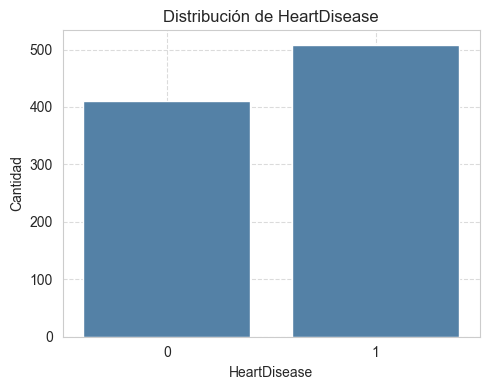

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(5, 4))
sns.countplot(x='HeartDisease', data=df, color='steelblue')
plt.title("Distribución de HeartDisease", fontsize=12)
plt.xlabel("HeartDisease")
plt.ylabel("Cantidad")
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar porcentaje de positivos y negativos
print("Porcentaje por clase (%):")
print(df['HeartDisease'].value_counts(normalize=True).mul(100).round(2))

plt.tight_layout()
plt.show()


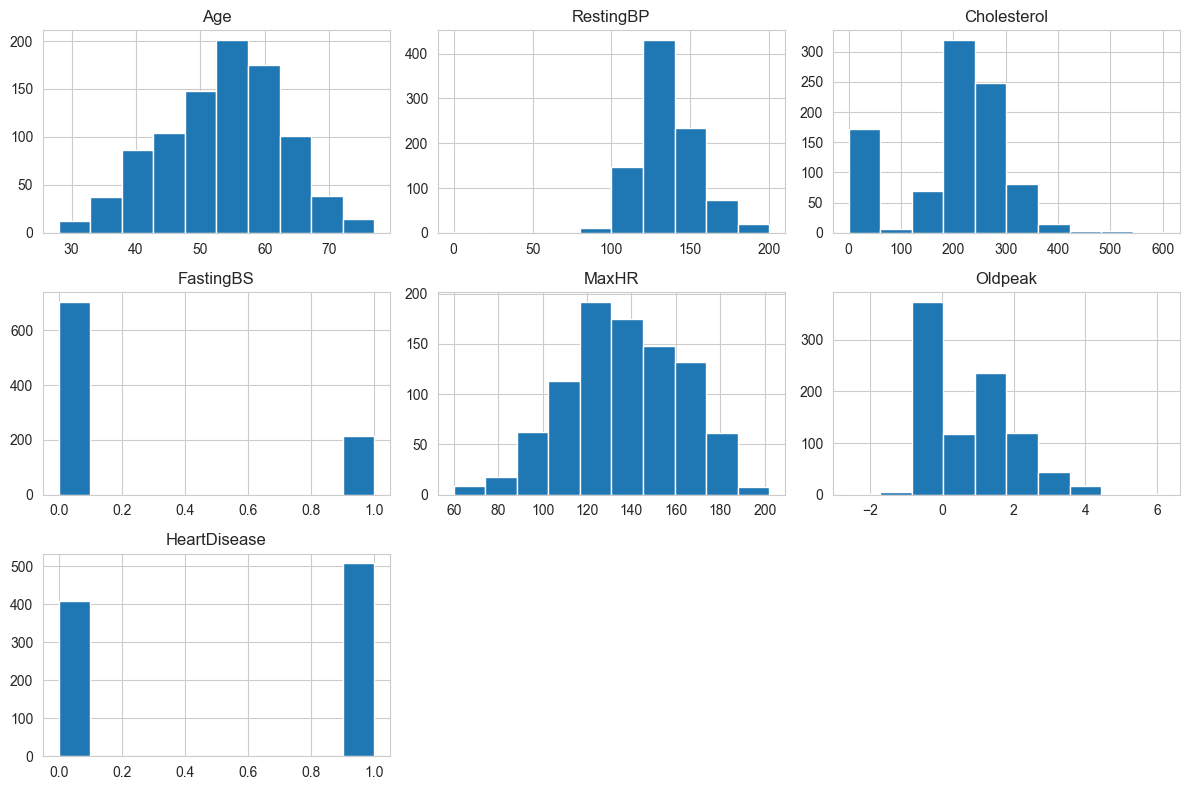

In [79]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

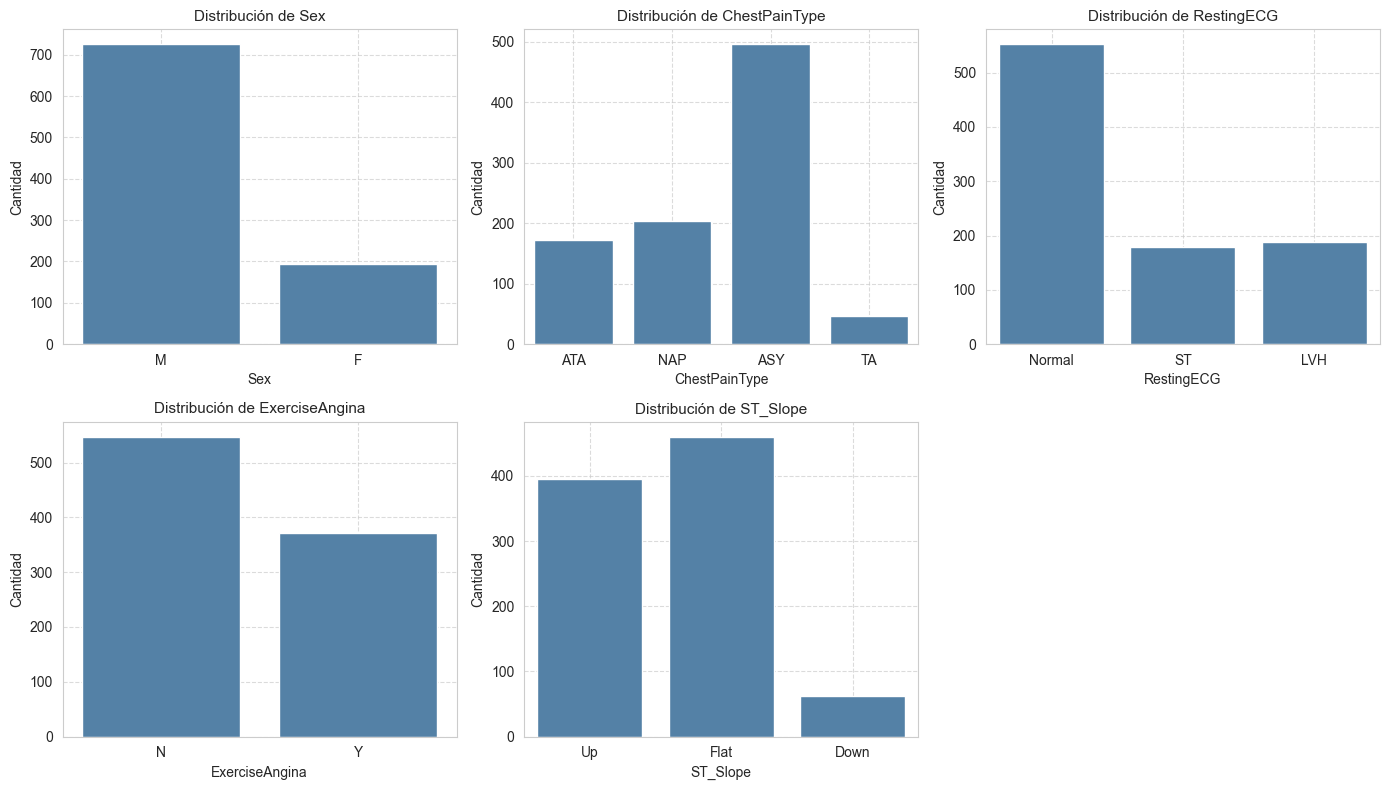

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables categóricas
categorical_vars = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Estilo visual general
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    sns.countplot(x=col, data=df, color='steelblue', ax=axes[i])
    axes[i].set_title(f"Distribución de {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Cantidad")
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Elimina ejes vacíos si hay más subplots que variables
for j in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [81]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [82]:
# Codificar variables categoricas
df_encoded = pd.get_dummies(df, drop_first=True)

In [83]:
from sklearn.preprocessing import StandardScaler

RSEED = 42
# Escalaramiento selectivo
# Separar X e y
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Variables numéricas continuas originales
num_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Crear una copia para mantener el resto de columnas igual
X_scaled = X.copy()

# Escalar solo las variables numéricas
scaler = StandardScaler()
X_scaled[num_vars] = scaler.fit_transform(X[num_vars])

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=RSEED
)

## Parte b

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# Modelo (puedes ajustar class_weight si detectaste desbalance)
clf_lr = LogisticRegression(max_iter=5000, solver='saga', random_state=RSEED, class_weight='balanced', penalty='l1', C=1.0)
clf_lr.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [86]:
# Predicciones
y_train_pred = clf_lr.predict(X_train)
y_test_pred = clf_lr.predict(X_test)

# Métricas
def metrics_report(y_true, y_pred, prefix=""):
    print(prefix + "Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print(prefix + "Accuracy:", accuracy_score(y_true, y_pred))
    print(prefix + "Precision:", precision_score(y_true, y_pred))
    print(prefix + "Recall:", recall_score(y_true, y_pred))
    print(prefix + "F1:", f1_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

print("== TRAIN ==")
metrics_report(y_train, y_train_pred, prefix="TRAIN ")
print("\n== TEST ==")
metrics_report(y_test, y_test_pred, prefix="TEST ")

== TRAIN ==
TRAIN Confusion matrix:
 [[276  52]
 [ 54 352]]
TRAIN Accuracy: 0.8555858310626703
TRAIN Precision: 0.8712871287128713
TRAIN Recall: 0.8669950738916257
TRAIN F1: 0.8691358024691358
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       328
           1       0.87      0.87      0.87       406

    accuracy                           0.86       734
   macro avg       0.85      0.85      0.85       734
weighted avg       0.86      0.86      0.86       734


== TEST ==
TEST Confusion matrix:
 [[71 11]
 [ 7 95]]
TEST Accuracy: 0.9021739130434783
TEST Precision: 0.8962264150943396
TEST Recall: 0.9313725490196079
TEST F1: 0.9134615384615384
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        82
           1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90 

## Parte d

In [87]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)

k = 6  # número de features para M2
selector = SelectKBest(chi2, k=k)
selector.fit(X_train_mm, y_train)
cols_idx = selector.get_support(indices=True)
cols_M2 = X_train.columns[cols_idx].tolist()
print("M2 selected features:", cols_M2)


# 2) Entrenar M2
clf_M2 = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=RSEED)
clf_M2.fit(X_train[cols_M2], y_train)

M2 selected features: ['FastingBS', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [88]:
# 3) M3: L1 regularization for feature selection
clf_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000, random_state=RSEED)
clf_l1.fit(X_train, y_train)
cols_M3 = X_train.columns[(clf_l1.coef_.ravel() != 0)].tolist()
print("M3 selected (non-zero coef) features:", cols_M3)

clf_M3 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000, random_state=RSEED)
# re-entrenar M3 sólo con features seleccionadas 
clf_M3.fit(X_train[cols_M3], y_train)


M3 selected (non-zero coef) features: ['Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [89]:
import numpy as np

def log_likelihood_from_proba(clf, X, y):
    # clf.predict_proba(X) -> shape (n,2), probs for class 0 and 1
    probs = clf.predict_proba(X)
    # prob of true class for each sample
    p_true = probs[np.arange(len(y)), y.astype(int)]
    ll = np.sum(np.log(p_true + 1e-12))  # suma log-prob
    return ll

def n_params_logistic(clf, X):
    # número de parámetros = n_features * 1 (coef por feature) + intercept(1)
    d = X.shape[1] + 1
    return d

# calcular para M1, M2, M3 (en train)
models = {
    'M1_all': clf_lr,
    'M2_subset': clf_M2,
    'M3_l1_selected': clf_M3
}
Xtr_map = {
    'M1_all': X_train,
    'M2_subset': X_train[cols_M2],
    'M3_l1_selected': X_train[cols_M3]
}

results = []
for name, model in models.items():
    Xloc = Xtr_map[name]
    ll = log_likelihood_from_proba(model, Xloc, y_train)
    d = n_params_logistic(model, Xloc)
    AIC = -2 * ll + 2 * d
    BIC = -2 * ll + d * np.log(Xloc.shape[0])
    results.append((name, ll, d, AIC, BIC))

import pandas as pd
df_info = pd.DataFrame(results, columns=['model','loglik','d','AIC','BIC'])
df_info


,model,loglik,d,AIC,BIC
0,M1_all,-241.880574,16,515.761147,589.337292
1,M2_subset,-268.523614,7,551.047227,583.236791
2,M3_l1_selected,-245.791257,11,513.582513,564.166113


In [90]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RSEED)
cv_scores = {}
for name, model in models.items():
    Xloc = Xtr_map[name]
    scores = cross_val_score(model, Xloc, y_train, cv=skf, scoring='f1')
    cv_scores[name] = scores
    print(name, "CV F1 mean:", scores.mean(), "std:", scores.std())

# añadir CV mean to df_info
df_info['CV_F1_mean'] = df_info['model'].map(lambda n: cv_scores[n].mean())
df_info['CV_F1_std'] = df_info['model'].map(lambda n: cv_scores[n].std())
df_info


M1_all CV F1 mean: 0.8587507441233534 std: 0.028599231982421088
M2_subset CV F1 mean: 0.8562084748555966 std: 0.02672382317230096
M3_l1_selected CV F1 mean: 0.8707001919386169 std: 0.024748204644675028


,model,loglik,d,AIC,BIC,CV_F1_mean,CV_F1_std
0,M1_all,-241.880574,16,515.761147,589.337292,0.858751,0.028599
1,M2_subset,-268.523614,7,551.047227,583.236791,0.856208,0.026724
2,M3_l1_selected,-245.791257,11,513.582513,564.166113,0.870700,0.024748


## Parte e

In [91]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(store_covariance=True)
lda.fit(X_train, y_train)

print(X_train.columns)

y_test_pred_lda = lda.predict(X_test)
# métricas
metrics_report(y_test, y_test_pred_lda, prefix="LDA TEST ")

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')
LDA TEST Confusion matrix:
 [[69 13]
 [ 7 95]]
LDA TEST Accuracy: 0.8913043478260869
LDA TEST Precision: 0.8796296296296297
LDA TEST Recall: 0.9313725490196079
LDA TEST F1: 0.9047619047619048
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

def lda_log_likelihood(lda_model, X, y):
    # Con densidad gaussiana completa
    # Obtener priors, means, covariance shared
    priors = lda_model.priors_          # shape (K,)
    means = lda_model.means_            # shape (K, M)
    # Shared covariance: LDA stores 'covariance_' for sklearn >0.24 under attribute .covariance_
    Sigma = lda_model.covariance_       # shape (M, M)
    ll = 0.0
    M = X.shape[1]
    for i in range(X.shape[0]):
        k = int(y.iloc[i]) if isinstance(y, pd.Series) else int(y[i])
        # compute multivariate normal pdf
        try:
            density = multivariate_normal.pdf(X[i,:], mean=means[k], cov=Sigma, allow_singular=True)
        except Exception:
            # fallback small regularization
            density = multivariate_normal.pdf(X[i,:], mean=means[k], cov=Sigma + 1e-6*np.eye(M), allow_singular=True)
        ll += np.log(priors[k] + 1e-12) + np.log(density + 1e-12)
    return ll

X_train_np = X_train.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=int)

ll_lda = lda_log_likelihood(lda, X_train_np, y_train_np)
print(ll_lda)


-7783.879688411251


In [93]:
K = len(lda.classes_)
M = X_train.shape[1]
print(K, M)
d_lda = (K - 1) + K*M + M*(M + 1)/2
AIC_lda = -2*ll_lda + 2*d_lda
BIC_lda = -2*ll_lda + d_lda * np.log(X_train.shape[0])
d_lda, AIC_lda, BIC_lda

print(f"d LDA: {d_lda}, AIC LDA: {AIC_lda}, BIC LDA: {BIC_lda}")

2 15
d LDA: 151.0, AIC LDA: 15869.759376822502, BIC LDA: 16564.134240143292


In [97]:
import numpy as np

def lda_loglik_conditional(lda_model, X, y):
    """
    Calcula la log-verosimilitud condicional log p(y|x) del modelo LDA,
    consistente con modelos discriminativos (como la regresión logística).
    """
    # Obtener probabilidades predichas p(y|x)
    proba = lda_model.predict_proba(X)
    # Evitar log(0)
    proba = np.clip(proba, 1e-12, 1 - 1e-12)
    # Sumar log p(y_i|x_i) según la clase verdadera
    ll = np.sum(np.log(proba[np.arange(len(y)), y]))
    return ll

# Luego calcula:
ll_lda = lda_loglik_conditional(lda, X_train_np, y_train_np)
d_lda = X_train.shape[1] + 1   # coherente con los modelos logísticos
AIC_lda = -2*ll_lda + 2*d_lda
BIC_lda = -2*ll_lda + d_lda * np.log(X_train.shape[0])

print(f"loglik (cond): {ll_lda:.3f}, d LDA: {d_lda}, AIC: {AIC_lda:.3f}, BIC: {BIC_lda:.3f}")


loglik (cond): -256.838, d LDA: 16, AIC: 545.675, BIC: 619.251


c:\Users\pbast\Desktop\Universidad\VIV Semestre\Aprendizaje de Máquinas\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


## Parte f

In [94]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

print(X_train.columns)
# SVM linear
svm_lin = SVC(kernel='linear', probability=True, random_state=RSEED)
svm_lin.fit(X_train, y_train)
y_test_pred_svm = svm_lin.predict(X_test)
metrics_report(y_test, y_test_pred_svm, prefix="SVM Linear TEST ")

# SVM RBF
svm_rbf = SVC(kernel='rbf', probability=True, random_state=RSEED)
svm_rbf.fit(X_train, y_train)
y_test_pred_svm_rbf = svm_rbf.predict(X_test)
metrics_report(y_test, y_test_pred_svm_rbf, prefix="SVM RBF TEST ")

# SVM poly
svm_poly = SVC(kernel='poly', degree=3, probability=True, random_state=RSEED)
svm_poly.fit(X_train, y_train)
y_test_pred_svm_poly = svm_poly.predict(X_test)
metrics_report(y_test, y_test_pred_svm_poly, prefix="SVM Poly TEST ")

# SVM sigmoid
svm_sigmoid = SVC(kernel='sigmoid', probability=True, random_state=RSEED)
svm_sigmoid.fit(X_train, y_train)
y_test_pred_svm_sigmoid = svm_sigmoid.predict(X_test)
metrics_report(y_test, y_test_pred_svm_sigmoid, prefix="SVM Sigmoid TEST ")


Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')
SVM Linear TEST Confusion matrix:
 [[67 15]
 [ 7 95]]
SVM Linear TEST Accuracy: 0.8804347826086957
SVM Linear TEST Precision: 0.8636363636363636
SVM Linear TEST Recall: 0.9313725490196079
SVM Linear TEST F1: 0.8962264150943396
              precision    recall  f1-score   support

           0       0.91      0.82      0.86        82
           1       0.86      0.93      0.90       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.88       184
weighted avg       0.88      0.88      0.88       184

SVM RBF TEST Confusion matrix:
 [[70 12]
 [ 6 96]]
SVM RBF TEST Accuracy: 0.9021739130434783
SVM RBF TEST Precision: 0.8888888888888888
SVM RBF TEST Recall: 0.9411764

In [95]:
from sklearn.calibration import CalibratedClassifierCV

svm_base = SVC(kernel='rbf', probability=False, random_state=RSEED)
cal_svm = CalibratedClassifierCV(svm_base, cv=5, method='sigmoid')
cal_svm.fit(X_train, y_train)


,estimator,SVC(random_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True


## Parte g

In [98]:
# Recolectar métricas test (ejemplo)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

final_rows = []

# helpers para obtener loglik/AIC/BIC si el modelo es probabilístico
def compute_aic_bic_for_clf(clf, Xtrain, ytrain):
    try:
        ll = log_likelihood_from_proba(clf, Xtrain, ytrain)
        d = Xtrain.shape[1] + 1
        AIC = -2*ll + 2*d
        BIC = -2*ll + d * np.log(Xtrain.shape[0])
        return ll, d, AIC, BIC
    except Exception as e:
        return np.nan, np.nan, np.nan, np.nan

# Eval a lista de modelos con los X usados para cada
eval_list = [
    ('Logistic_M1', clf_lr, X_train),
    ('Logistic_M2', clf_M2, X_train[cols_M2]),
    ('Logistic_M3', clf_M3, X_train[cols_M3]),
    ('LDA', lda, X_train),
    ('SVM_linear', svm_lin, X_train),
    ('SVM_rbf', svm_rbf, X_train)
]

from sklearn.model_selection import cross_val_score

for name, model, Xtr in eval_list:
    # Seleccionar test correspondiente
    if name.startswith('Logistic_M2'):
        Xtest_loc = X_test[cols_M2]
        Xtrain_loc = X_train[cols_M2]
    elif name.startswith('Logistic_M3'):
        Xtest_loc = X_test[cols_M3]
        Xtrain_loc = X_train[cols_M3]
    else:
        Xtest_loc = X_test
        Xtrain_loc = Xtr

    # Predicciones en test
    ypred = model.predict(Xtest_loc)
    acc = accuracy_score(y_test, ypred)
    prec = precision_score(y_test, ypred)
    rec = recall_score(y_test, ypred)
    f1 = f1_score(y_test, ypred)

    # LogLik / AIC / BIC
    ll, d, AIC, BIC = compute_aic_bic_for_clf(model, Xtrain_loc, y_train)

    # 🔹 Validación cruzada (5-fold)
    f1_cv_scores = cross_val_score(model, Xtrain_loc, y_train, cv=5, scoring='f1')
    f1_cv_mean = f1_cv_scores.mean()
    f1_cv_std = f1_cv_scores.std()

    # Agregar todo
    final_rows.append((name, acc, prec, rec, f1, ll, d, AIC, BIC, f1_cv_mean, f1_cv_std))

# Construir DataFrame final con nuevas columnas
df_final = pd.DataFrame(
    final_rows,
    columns=['model','accuracy','precision','recall','f1','loglik','d','AIC','BIC','CV F1 (mean)','CV F1 (std)']
)

df_final


,model,accuracy,precision,recall,f1,loglik,d,AIC,BIC,CV F1 (mean),CV F1 (std)
0,Logistic_M1,0.902174,0.896226,0.931373,0.913462,-241.880574,16,515.761147,589.337292,0.857525,0.027713
1,Logistic_M2,0.858696,0.858491,0.892157,0.875000,-268.523614,7,551.047227,583.236791,0.862600,0.028923
2,Logistic_M3,0.891304,0.886792,0.921569,0.903846,-245.791257,11,513.582513,564.166113,0.871169,0.028046
3,LDA,0.891304,0.879630,0.931373,0.904762,-256.837526,16,545.675053,619.251197,0.866721,0.028224
4,SVM_linear,0.880435,0.863636,0.931373,0.896226,-243.987100,16,519.974201,593.550345,0.868536,0.030817
5,SVM_rbf,0.902174,0.888889,0.941176,0.914286,-200.450821,16,432.901641,506.477785,0.881368,0.023778
